In [2]:
import numpy as np
import matplotlib.pyplot as plt 
from tensorflow.keras.datasets import mnist
from tensorflow import keras 
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data() 

In [4]:
x_train = x_train / 255
x_test = x_test / 255

y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

In [5]:
x_train = np.expand_dims(x_train, axis=3)
x_test = np.expand_dims(x_test, axis=3)
print( x_train.shape )

(60000, 28, 28, 1)


In [ ]:
model = keras.Sequential([
    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28, 28, 1)), # 32 ядра и на выходе тоже 32    , (3, 3) - shape ядра
    MaxPooling2D((2, 2), strides=2), # (2, 2) <- размер ядра, strides=2 сдвиг вправо на 2 пикселя 
    Conv2D(64, (3,3), padding='same', activation='relu'), 
    MaxPooling2D((2, 2), strides=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10,  activation='softmax')
])

c:\Users\iliko\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer='adam',
             loss='categorical_crossentropy',
             metrics=['accuracy'])

model.fit(x_train, y_train_cat, batch_size=32, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9623 - loss: 0.1203
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9876 - loss: 0.0398
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9912 - loss: 0.0265
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9935 - loss: 0.0199
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9954 - loss: 0.0141


In [9]:
preds = model.predict(x_test)
preds_cls = preds.argmax(axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [10]:
from sklearn.metrics import accuracy_score

print(f'test acc: {accuracy_score(y_test, preds_cls)*100:.2f}% ({(y_test == preds_cls).sum()} out of {y_test.shape[0]})')

test acc: 99.14% (9914 out of 10000)


In [11]:
! pip install gdown


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
! gdown https://drive.google.com/uc?id=1JwtdQeJ-GEg4Iba3KiILUjgAMPLI9JtL -O apparel_small.zip
! unzip -d dataset apparel_small.zip

Downloading...
From (original): https://drive.google.com/uc?id=1JwtdQeJ-GEg4Iba3KiILUjgAMPLI9JtL
From (redirected): https://drive.google.com/uc?id=1JwtdQeJ-GEg4Iba3KiILUjgAMPLI9JtL&confirm=t&uuid=9df386be-c342-416c-ab0f-0dfb8c1580ed
To: c:\Users\iliko\OneDrive\Рабочий стол\ML\Conventional\apparel_small.zip

  0%|          | 0.00/61.8M [00:00<?, ?B/s]
  1%|          | 524k/61.8M [00:00<00:33, 1.85MB/s]
  3%|▎         | 1.57M/61.8M [00:00<00:14, 4.17MB/s]
  7%|▋         | 4.19M/61.8M [00:00<00:05, 10.5MB/s]
 10%|█         | 6.29M/61.8M [00:00<00:04, 12.7MB/s]
 13%|█▎        | 7.86M/61.8M [00:00<00:06, 8.88MB/s]
 20%|█▉        | 12.1M/61.8M [00:01<00:03, 14.9MB/s]
 23%|██▎       | 14.2M/61.8M [00:01<00:04, 11.9MB/s]
 27%|██▋       | 16.8M/61.8M [00:01<00:03, 14.0MB/s]
 31%|███       | 18.9M/61.8M [00:01<00:03, 13.5MB/s]
 33%|███▎      | 20.4M/61.8M [00:01<00:03, 13.1MB/s]
 36%|███▌      | 22.0M/61.8M [00:01<00:03, 12.9MB/s]
 38%|███▊      | 23.6M/61.8M [00:02<00:03, 11.5MB/s]
 41%|████   

In [13]:
import os
import numpy as np


paths = []
for dirname, _, filenames in os.walk('dataset/'):
    for filename in filenames:
        paths.append(os.path.join(dirname, filename))


np.random.seed(1)
np.random.shuffle(paths)

paths[:10]

['dataset/blue_shoes\\192.jpg',
 'dataset/black_shoes\\85.jpg',
 'dataset/black_shoes\\6.jpg',
 'dataset/black_shoes\\686.jpg',
 'dataset/blue_shoes\\235.jpg',
 'dataset/black_shoes\\187.jpg',
 'dataset/blue_dress\\246.jpg',
 'dataset/blue_pants\\53.jpg',
 'dataset/white_dress\\628.jpg',
 'dataset/black_shoes\\106.jpg']

In [14]:
len(paths)

5028

dataset/black_shoes\85.jpg
(256, 256, 3)


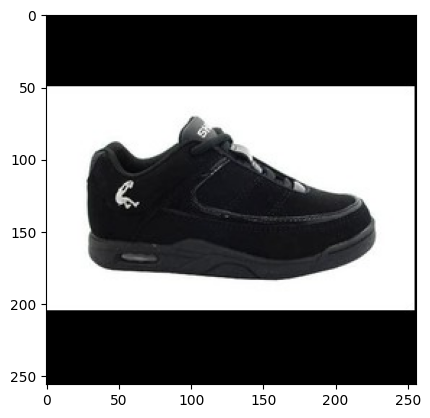

In [15]:
import matplotlib.pyplot as plt

idx = 1
print(paths[idx])
img = plt.imread(paths[idx])
print(img.shape)
plt.imshow(img)

In [16]:
train_size = 0.7 # 70% процентов от всего датасета, 30% на тестирование

thresh = round(len(paths) * train_size) # получаем 70% для обучения выборки, thresh - порог

train_paths = paths[:thresh]
test_paths = paths[thresh:]

len(train_paths), len(test_paths)

(3520, 1508)

In [17]:
paths[0]

'dataset/blue_shoes\\192.jpg'

In [18]:
paths[0].split('\\')[-2].split('_')[1]

'shoes'

In [19]:
train_labels = []

for path in train_paths:
    label = path.split('\\')[-2].split('_')[1]
    train_labels.append(label)

test_labels = []
for path in test_paths:
    label = path.split('\\')[-2].split('_')[1]
    test_labels.append(label)

train_labels[:10]

['shoes',
 'shoes',
 'shoes',
 'shoes',
 'shoes',
 'shoes',
 'dress',
 'pants',
 'dress',
 'shoes']

In [20]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()
train_classes = le.fit_transform(train_labels)
test_classes = le.transform(test_labels)

train_classes

array([2, 2, 2, ..., 2, 1, 0], shape=(3520,))

In [21]:
classes_names = le.classes_
classes_names

array(['dress', 'pants', 'shoes'], dtype='<U5')

In [22]:
from tensorflow.keras.utils import Sequence


class DataGenerator(Sequence):
    def __init__(self, paths, labels, batch_size=32):
        self.batch_size = batch_size
        self.paths = paths
        self.labels = labels

    def __len__(self):
        return int(np.round(len(self.paths) / self.batch_size))

    def __getitem__(self, index):
        X = self.paths[index * self.batch_size : (index+1) * self.batch_size]
        y = self.labels[index * self.batch_size : (index+1) * self.batch_size]
        X = np.array([self.load_img(i) for i in X])
        return X, np.array(y)

    @staticmethod
    def load_img(path):
        img = plt.imread(path)
        img = img / 255.0
        return img

In [23]:
train_data = DataGenerator(train_paths, train_classes)
test_data = DataGenerator(test_paths, test_classes)

(32, 256, 256, 3)
2


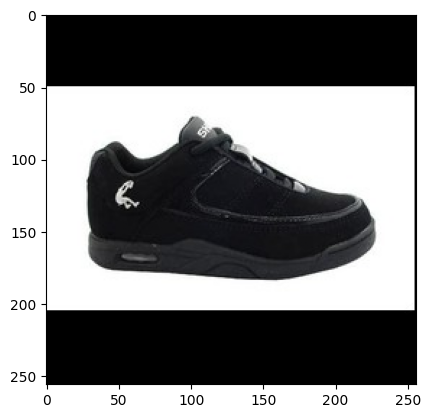

In [24]:
for X, y in train_data:
    print(X.shape)
    plt.imshow(X[1])
    print(y[1])
    break

In [25]:
model_1 = keras.Sequential([
    Conv2D(3, (3,3), padding='same', activation='relu', input_shape=(256, 256, 3)),
    MaxPooling2D((2, 2), strides=2),
    Conv2D(6, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2, 2), strides=2),
    Flatten(),
    Dense(3,  activation='softmax')
])

c:\Users\iliko\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 256, 256, 3)    │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 24576)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │        73,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,983 (289.00 KB)

 Trainable params: 73,983 (289.00 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
from keras import losses

model_1.compile(
    optimizer='adam',
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [28]:
model_1.fit(
    train_data,
    epochs=1,
    validation_data=test_data
)

c:\Users\iliko\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


110/110 ━━━━━━━━━━━━━━━━━━━━ 19s 170ms/step - accuracy: 0.7415 - loss: 0.7723 - val_accuracy: 0.8491 - val_loss: 0.4029
